Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=134027936040240 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,2.423000,0.847322,0.653333,0.657380,0.667762,0.653333,0.166543,49.963044
2,1.276700,0.563761,0.796667,0.798707,0.802453,0.796667,0.105532,31.659510
3,0.976600,0.428723,0.840000,0.841384,0.845122,0.840000,0.078062,23.418741
4,0.659500,0.360218,0.873333,0.873770,0.874418,0.873333,0.064678,19.403268
5,0.588800,0.333781,0.893333,0.893783,0.894608,0.893333,0.059741,17.922438
6,0.455800,0.318436,0.896667,0.897172,0.898269,0.896667,0.056650,16.994861
7,0.404600,0.313385,0.900000,0.900566,0.901775,0.900000,0.055673,16.701776


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=26.78s tok/s=0.0 ex/s=0.00 peak_mem=2.60GiB lr=9.13e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.53s tok/s=154619.0 ex/s=1207.96
[EVALUATION_PERFORMANCE] accuracy=0.6533 cost=$0.02 accuracy_per_$=41.62
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.127789046653144e-06 id=134027936040240 hyperparams={'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.127789046653144e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.70s tok/s=117113.5 ex/s=914.95
[EVALUATION_PERFORMANCE] accuracy=0.8933 cost=$0.18 accuracy_per_$=5.09

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 7.0,
 'eval_accuracy': 0.8933333333333333,
 'eval_f1_macro': 0.8925298852467248,
 'eval_loss': 0.2734760046005249,
 'eval_mse': 0.04801455485364021,
 'eval_precision_macro': 0.8928164241898706,
 'eval_recall_macro': 0.8933333333333334,
 'eval_runtime': 0.7657,
 'eval_samples_per_second': 391.822,
 'eval_sse': 14.404366456092063,
 'eval_steps_per_second': 6.53}


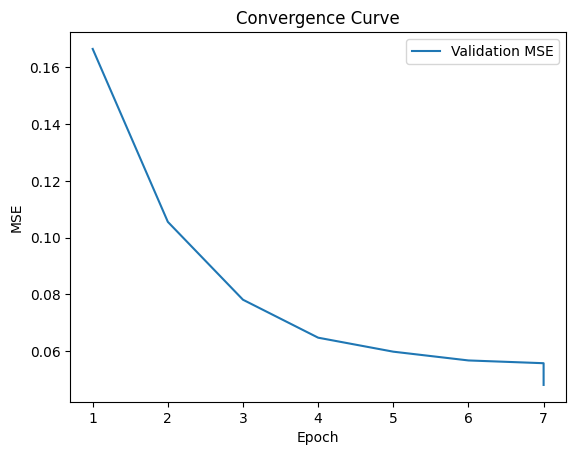

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

